In [1]:
import subprocess
subprocess.run(["pip", "install", "--user", "pandas", "matplotlib", "seaborn", "pandasql"], check=True)

CompletedProcess(args=['pip', 'install', '--user', 'pandas', 'matplotlib', 'seaborn', 'pandasql'], returncode=0)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandasql import sqldf

# Load the dataset
df = pd.read_csv('vgsales.csv')

# First look
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (16598, 11)

First 5 rows:


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [3]:
# Check data quality
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

Shape: (16598, 11)

Missing values:
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

Data types:
Rank              int64
Name                str
Platform            str
Year            float64
Genre               str
Publisher           str
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object


In [4]:
# Clean the data
df_clean = df.dropna(subset=['Year'])
df_clean = df_clean[df_clean['Year'] > 0]

# Convert Year to integer so it displays cleanly
df_clean = df_clean.copy()
df_clean['Year'] = df_clean['Year'].astype(int)

# Confirm cleaning
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Rows removed:", df.shape[0] - df_clean.shape[0])

Original shape: (16598, 11)
Cleaned shape: (16327, 11)
Rows removed: 271


C:\Users\asus\AppData\Local\Temp\ipykernel_25704\2670590686.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_sales.values, y=genre_sales.index, palette='Blues_r')


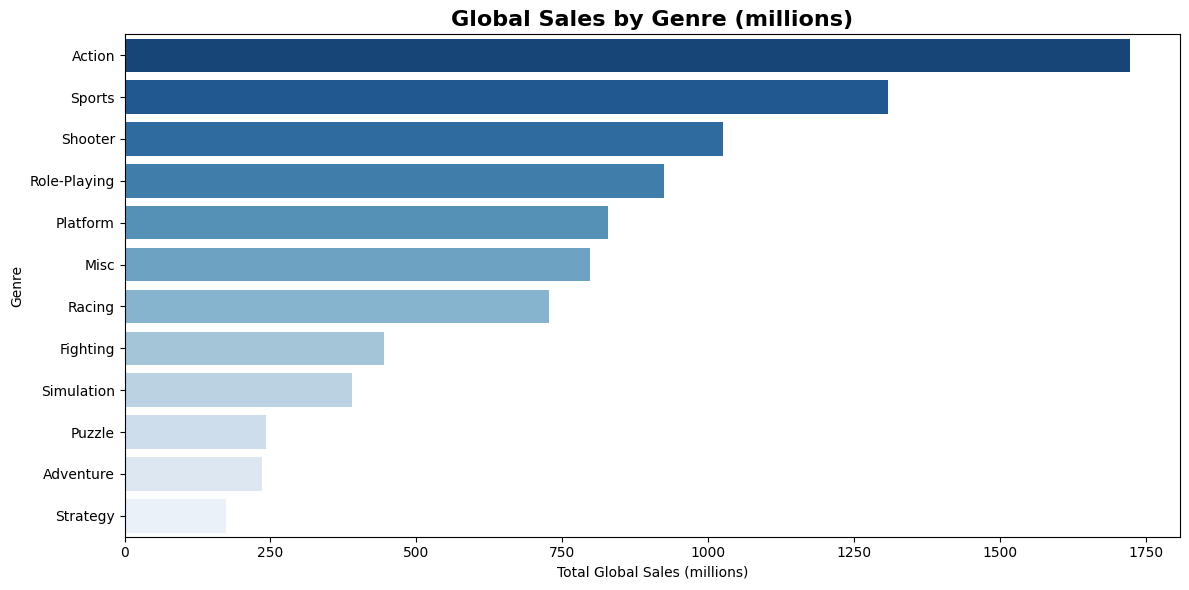

           Genre  Total_Sales
0         Action      1722.88
1         Sports      1309.24
2        Shooter      1026.20
3   Role-Playing       923.84
4       Platform       829.15
5           Misc       797.62
6         Racing       726.77
7       Fighting       444.05
8     Simulation       390.16
9         Puzzle       242.22
10     Adventure       234.80
11      Strategy       173.43


In [5]:
# ---- PYTHON APPROACH ----
genre_sales = df_clean.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_sales.values, y=genre_sales.index, palette='Blues_r')
plt.title('Global Sales by Genre (millions)', fontsize=16, fontweight='bold')
plt.xlabel('Total Global Sales (millions)')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('chart1_sales_by_genre.png', dpi=150)
plt.show()

# ---- SQL APPROACH ----
query = """
SELECT Genre, 
       ROUND(SUM(Global_Sales), 2) AS Total_Sales
FROM df_clean
GROUP BY Genre
ORDER BY Total_Sales DESC
"""
result = sqldf(query, locals())
print(result)

C:\Users\asus\AppData\Local\Temp\ipykernel_25704\2513588038.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=platform_sales.values, y=platform_sales.index, palette='Oranges_r')


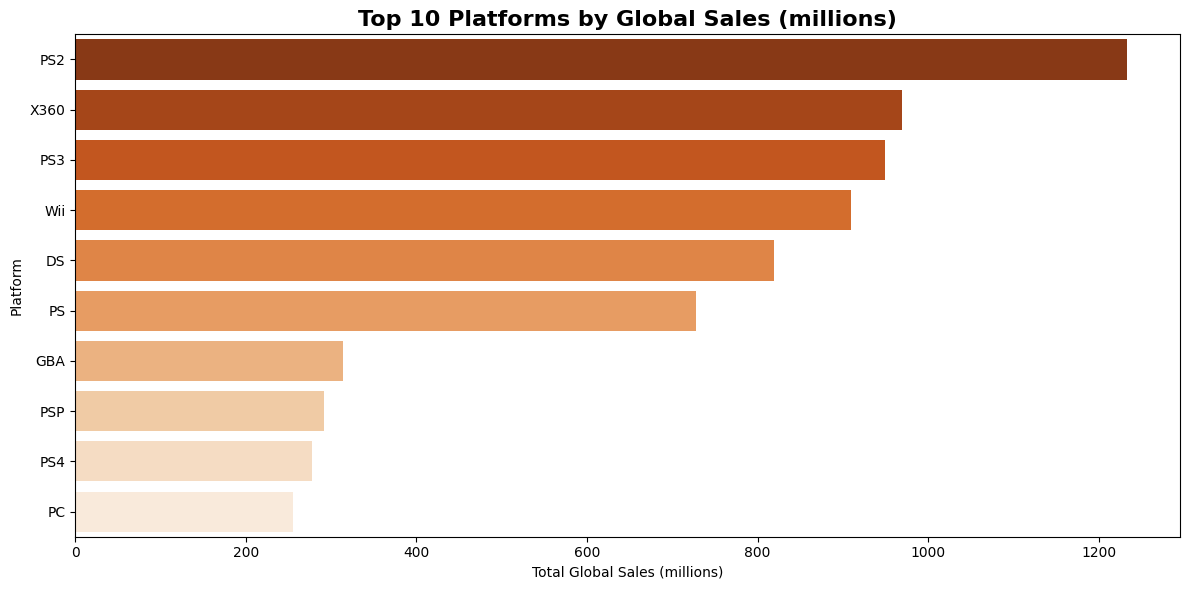

  Platform  Total_Sales  Total_Games
0      PS2      1233.46         2127
1     X360       969.61         1235
2      PS3       949.35         1304
3      Wii       909.81         1290
4       DS       818.96         2133
5       PS       727.39         1189
6      GBA       313.56          811
7      PSP       291.71         1197
8      PS4       278.10          336
9       PC       255.05          943


In [6]:
# ---- PYTHON APPROACH ----
platform_sales = df_clean.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=platform_sales.values, y=platform_sales.index, palette='Oranges_r')
plt.title('Top 10 Platforms by Global Sales (millions)', fontsize=16, fontweight='bold')
plt.xlabel('Total Global Sales (millions)')
plt.ylabel('Platform')
plt.tight_layout()
plt.savefig('chart2_sales_by_platform.png', dpi=150)
plt.show()

# ---- SQL APPROACH ----
query = """
SELECT Platform,
       ROUND(SUM(Global_Sales), 2) AS Total_Sales,
       COUNT(Name) AS Total_Games
FROM df_clean
GROUP BY Platform
ORDER BY Total_Sales DESC
LIMIT 10
"""
result = sqldf(query, locals())
print(result)

C:\Users\asus\AppData\Local\Temp\ipykernel_25704\79659032.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=publisher_sales.values, y=publisher_sales.index, palette='Greens_r')


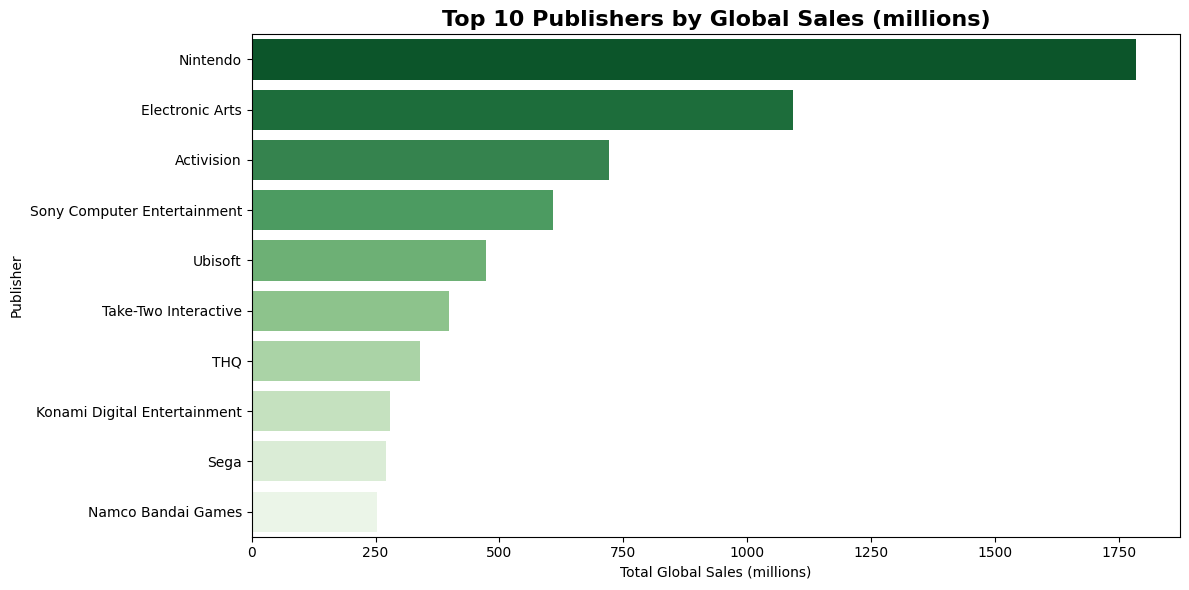

                      Publisher  Total_Sales
0                      Nintendo      1784.43
1               Electronic Arts      1093.39
2                    Activision       721.41
3   Sony Computer Entertainment       607.28
4                       Ubisoft       473.54
5          Take-Two Interactive       399.30
6                           THQ       340.44
7  Konami Digital Entertainment       278.56
8                          Sega       270.70
9            Namco Bandai Games       253.65


In [7]:
# ---- PYTHON APPROACH ----
publisher_sales = df_clean.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=publisher_sales.values, y=publisher_sales.index, palette='Greens_r')
plt.title('Top 10 Publishers by Global Sales (millions)', fontsize=16, fontweight='bold')
plt.xlabel('Total Global Sales (millions)')
plt.ylabel('Publisher')
plt.tight_layout()
plt.savefig('chart3_sales_by_publisher.png', dpi=150)
plt.show()

# ---- SQL APPROACH ----
query = """
SELECT Publisher,
       ROUND(SUM(Global_Sales), 2) AS Total_Sales
FROM df_clean
GROUP BY Publisher
ORDER BY Total_Sales DESC
LIMIT 10
"""

result = sqldf(query, locals())
print(result)


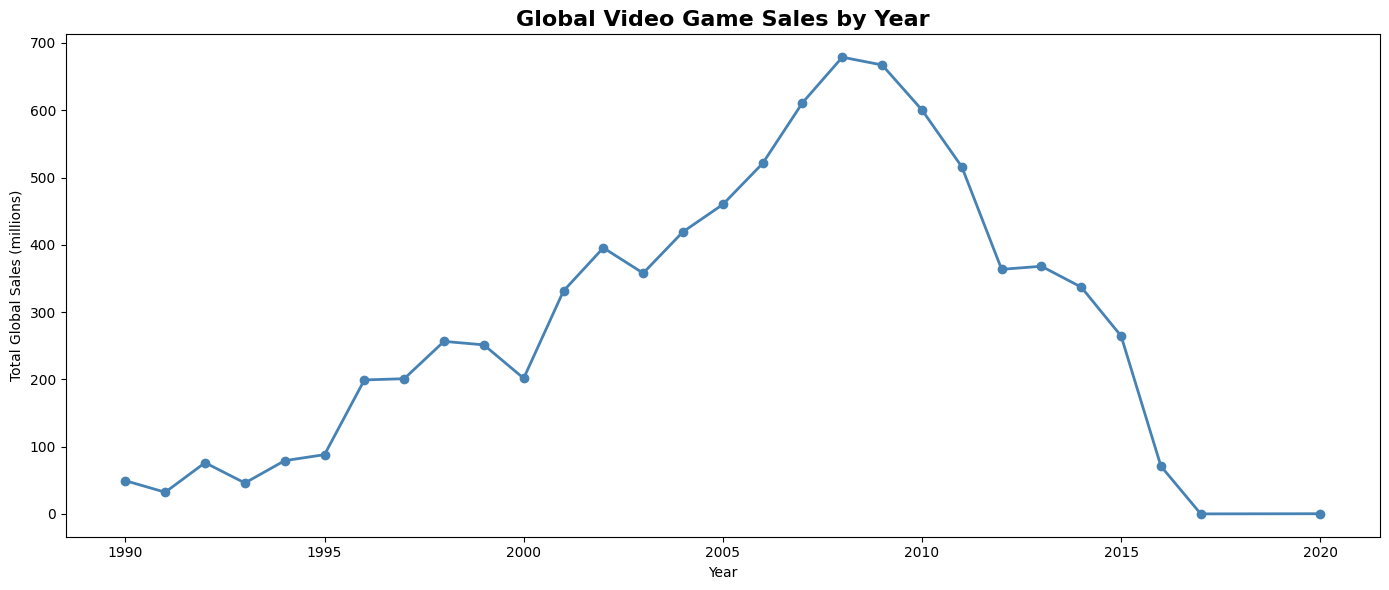

    Year  Total_Sales
0   1990        49.39
1   1991        32.23
2   1992        76.16
3   1993        45.98
4   1994        79.17
5   1995        88.11
6   1996       199.15
7   1997       200.98
8   1998       256.47
9   1999       251.27
10  2000       201.56
11  2001       331.47
12  2002       395.52
13  2003       357.85
14  2004       419.31
15  2005       459.94
16  2006       521.04
17  2007       611.13
18  2008       678.90
19  2009       667.30
20  2010       600.45
21  2011       515.99
22  2012       363.54
23  2013       368.11
24  2014       337.05
25  2015       264.44
26  2016        70.93
27  2017         0.05
28  2020         0.29


In [8]:
# ---- PYTHON APPROACH ----
yearly_sales = df_clean[df_clean['Year'] >= 1990].groupby('Year')['Global_Sales'].sum()

plt.figure(figsize=(14, 6))
yearly_sales.plot(kind='line', marker='o', color='steelblue', linewidth=2)
plt.title('Global Video Game Sales by Year', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Global Sales (millions)')
plt.tight_layout()
plt.savefig('chart4_sales_by_year.png', dpi=150)
plt.show()

# ---- SQL APPROACH ----
query = """
SELECT Year,
       ROUND(SUM(Global_Sales), 2) AS Total_Sales
FROM df_clean
WHERE Year >= 1990
GROUP BY Year
ORDER BY Year ASC
"""
result = sqldf(query, locals())
print(result)

C:\Users\asus\AppData\Local\Temp\ipykernel_25704\4149868482.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=best_selling_games['Global_Sales'], y=best_selling_games['Name'], palette='Purples_r')


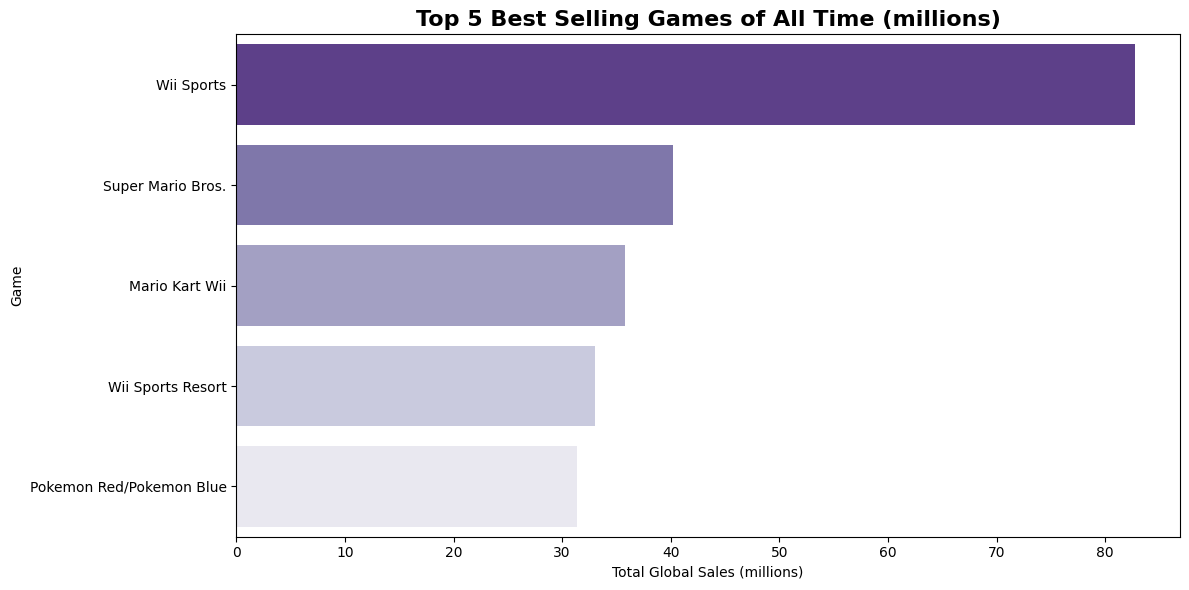

                       Name  Total_Sales
0                Wii Sports        82.74
1         Super Mario Bros.        40.24
2            Mario Kart Wii        35.82
3         Wii Sports Resort        33.00
4  Pokemon Red/Pokemon Blue        31.37


In [9]:
best_selling_games = df_clean.nlargest(5, 'Global_Sales')

plt.figure(figsize=(12, 6))
sns.barplot(x=best_selling_games['Global_Sales'], y=best_selling_games['Name'], palette='Purples_r')
plt.title('Top 5 Best Selling Games of All Time (millions)', fontsize=16, fontweight='bold')
plt.xlabel('Total Global Sales (millions)')
plt.ylabel('Game')
plt.tight_layout()
plt.savefig('chart5_best_selling_games.png', dpi=150)
plt.show()

query = """
SELECT Name,
       ROUND(Global_Sales, 2) AS Total_Sales
FROM df_clean
ORDER BY Global_Sales DESC
LIMIT 5
"""
result = sqldf(query, locals())
print(result)